In [1]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

In [2]:
%%capture
!pip -q install lightning torchinfo

# **실습:  Convolutional Auto Encoder**


## **Import Module**

In [3]:
import torch
from torch import nn
from torch.nn import functional as F
from torchmetrics import functional as FM
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
import torchvision
from torchinfo import summary

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

device ='cuda:0'
torch.__version__,L.__version__

('2.8.0+cu126', '2.5.5')

## **DataSet**

### Load

In [4]:
from torchvision.datasets import FashionMNIST, MNIST

class AddNoise:
    def __init__(self, noise_rate=0.1):
        self.noise_rate=noise_rate
    def __call__(self, sample):
        image = np.asarray(sample.reshape(-1,))
        image += self.noise_rate * np.random.randn(image.shape[0])
        image = torch.from_numpy(image).to(torch.float32)
        image = image.view(1, 28, 28)
        return  image

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    AddNoise(),])

download_root = './MNIST_DATASET'
train_dataset = MNIST(download_root, transform=transform, train=True, download=True)
test_dataset = MNIST(download_root, transform=transform, train=False, download=True)

trainDataLoader = DataLoader(train_dataset, batch_size=512, shuffle=True, num_workers=4)
testDataLoader = DataLoader(test_dataset, batch_size=512, shuffle=False, num_workers=4)

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.08MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 160kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]


In [5]:
# Print out the shape
ps(train_dataset[0][0])
p(train_dataset[0][1])

[] Shapetorch.Size([1, 28, 28])
[]:
Type: <class 'int'>
Values: 5


## **Model**

### Define

In [6]:
# AE4 model
class AE4(L.LightningModule):
    def __init__(self):
        super(AE4, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.BatchNorm2d(16),
            nn.Conv2d(16, 8, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, padding=1) )

        self.decoder = nn.Sequential(
            nn.Conv2d(8, 8, 3, padding=1),
            nn.ReLU(),
            nn.Upsample((8,8)),
            nn.Conv2d(8, 16, 3, padding=1),
            nn.ReLU(),
            nn.Upsample((16,16)),
            nn.BatchNorm2d(16),
            nn.Conv2d(16, 32, 3, padding=0),
            nn.ReLU(),
            nn.Upsample((28,28)),
            nn.Conv2d(32, 1, 3, padding=1),
            nn.Sigmoid() )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

    def training_step(self, batch, batch_idx):
        x, _ = batch
        decoded = self(x)
        loss_mse = F.mse_loss(decoded, x)
        metrics={'loss':loss_mse}
        self.log_dict(metrics,prog_bar=True)
        return metrics

    def validation_step(self, batch, batch_idx):
        x, _ = batch
        decoded = self(x)
        loss_mse = F.mse_loss(decoded, x)
        metrics={'val_loss':loss_mse}
        self.log_dict(metrics,prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters())

ae4 = AE4()#.to(device)
summary(ae4, input_size=(8, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
AE4                                      [8, 1, 28, 28]            --
├─Sequential: 1-1                        [8, 8, 4, 4]              --
│    └─Conv2d: 2-1                       [8, 32, 28, 28]           320
│    └─ReLU: 2-2                         [8, 32, 28, 28]           --
│    └─MaxPool2d: 2-3                    [8, 32, 14, 14]           --
│    └─Conv2d: 2-4                       [8, 16, 14, 14]           4,624
│    └─ReLU: 2-5                         [8, 16, 14, 14]           --
│    └─MaxPool2d: 2-6                    [8, 16, 7, 7]             --
│    └─BatchNorm2d: 2-7                  [8, 16, 7, 7]             32
│    └─Conv2d: 2-8                       [8, 8, 7, 7]              1,160
│    └─ReLU: 2-9                         [8, 8, 7, 7]              --
│    └─MaxPool2d: 2-10                   [8, 8, 4, 4]              --
├─Sequential: 1-2                        [8, 1, 28, 28]            --
│    └─C

### Fit

In [7]:
%%time
ae4 = AE4()

name="AE4"
logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=15, logger=logger,
                  limit_train_batches=0.5,limit_val_batches=0.5)
trainer.fit(ae4, trainDataLoader, testDataLoader)
# Wall time: 1min 12s

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name    | Type      

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=15` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


CPU times: user 19.2 s, sys: 4.31 s, total: 23.5 s
Wall time: 55.6 s


In [8]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
df = history.groupby('epoch').last().drop('step', axis=1)

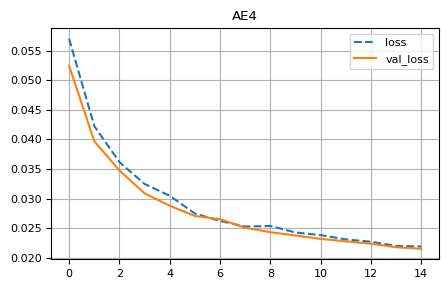

In [9]:
h1 = df

plt.figure(figsize=(5, 3))
plt.title(f"{name}")
plt.plot(h1['loss'],'--', label='loss')
plt.plot(h1['val_loss'],'-', label='val_loss')
#plt.ylim(0.7, 1)
#plt.semilogy()
plt.legend()
plt.grid()
plt.show()

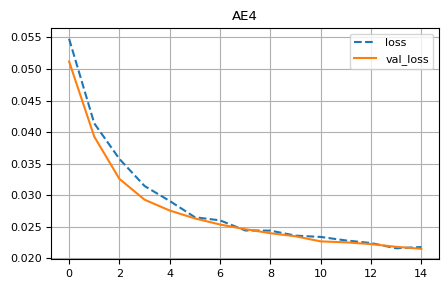

### Predict

In [10]:
# Input image
ps(test_dataset[0][0].unsqueeze(dim=0)) #(bs,ch,28,28)

[] Shapetorch.Size([1, 1, 28, 28])


In [11]:
# Decoded image
ps(ae4(test_dataset[0][0].unsqueeze(dim=0)))

[] Shapetorch.Size([1, 1, 28, 28])


In [12]:
# Predict
decoded_imgs = []
for i in range(9):
    decoded_imgs.append(ae4(test_dataset[i][0].unsqueeze(dim=0)))

ps(decoded_imgs[1])

[] Shapetorch.Size([1, 1, 28, 28])


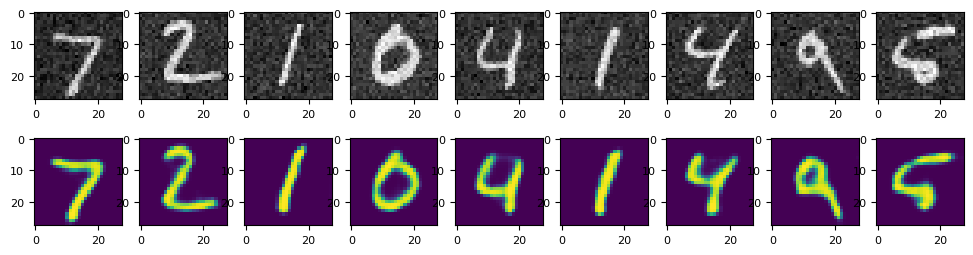

In [13]:
plt.figure(figsize=(12, 3))
num_imgs = 9
for i in range(num_imgs):
    # display original
    ax = plt.subplot(2, num_imgs, i + 1)
    true_img = test_dataset[i][0].reshape(28, 28)
    plt.imshow(true_img, cmap='gray')

    # display reconstruction
    ax = plt.subplot(2, num_imgs, i + 1 + num_imgs)
    reconstructed_img = decoded_imgs[i].reshape(28,28)
    plt.imshow(reconstructed_img.detach().numpy())
plt.show()

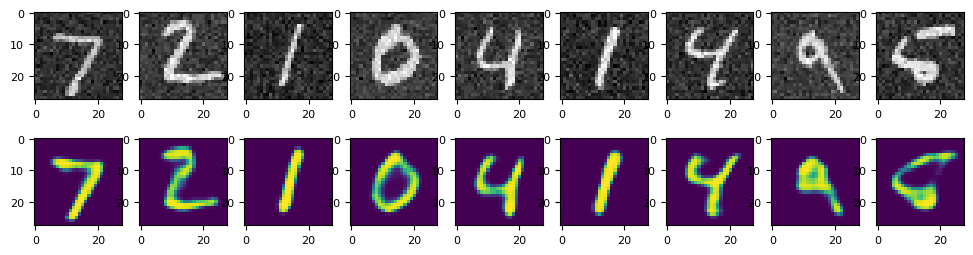

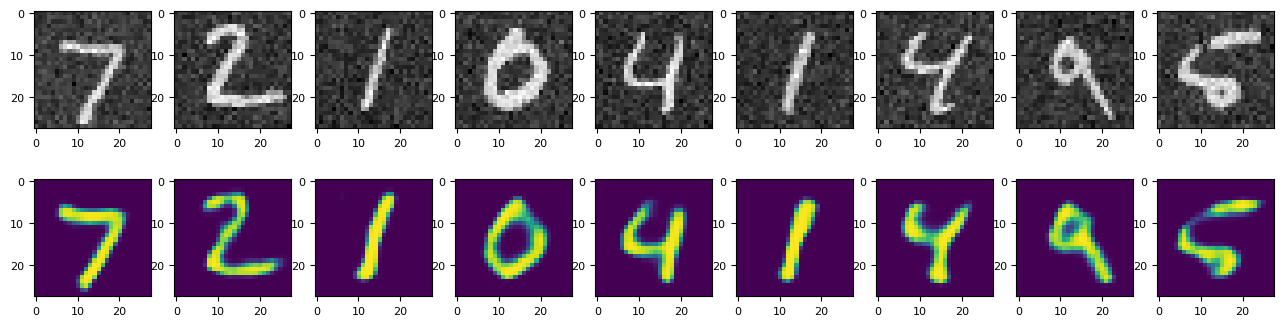

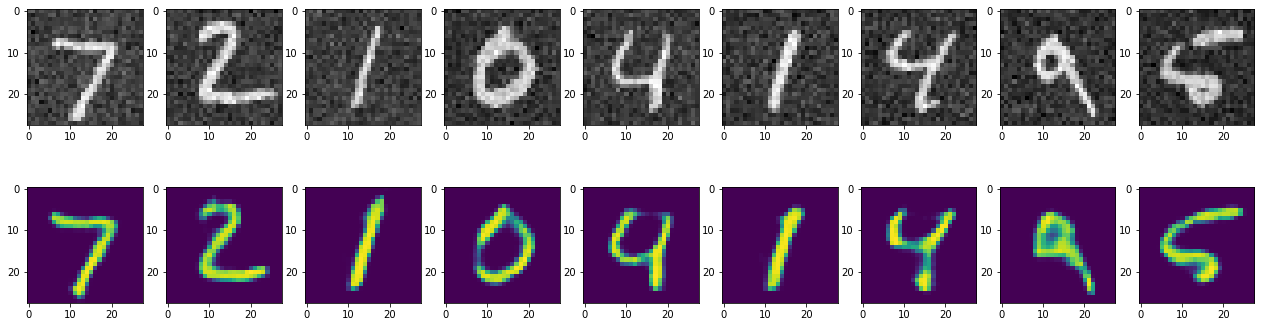

## **Analysis**

### Plot

## **실습 과제**

### 과제 1. Data set을 바꾸고 noise가 추가 되는 경우 결과가 얼마나 다른지 확인하자
#### -- FashionMNIST를읽고, "noise_on = False" 를 "True"로 변경
#### -- Noisy data로 다시 학습하여 결과를 확인하자
#### -- 결과 이미지의 차이를 비교해 보자
